In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import pypsa
import contextlib
import io
import logging

logging.getLogger("pypsa").setLevel(logging.WARNING)
logging.getLogger("linopy").setLevel(logging.WARNING)

In [2]:
network_path = Path("/home/sammy/pypsa-eur/results/test-elec-365/networks/base_s_5_elec_.nc")
n = pypsa.Network(network_path)

print(n)

PyPSA Network 'Unnamed Network'


In [3]:
n

PyPSA Network 'Unnamed Network'
-------------------------------
Components:
 - Bus: 10
 - Carrier: 17
 - Generator: 29
 - GlobalConstraint: 1
 - Line: 6
 - Link: 10
 - Load: 5
 - StorageUnit: 5
 - Store: 5
 - SubNetwork: 1
Snapshots: 13

Installed (Optimised) Generation Capacity

In [4]:
capacity = n.generators.groupby("carrier")["p_nom_opt"].sum().sort_values()
capacity

carrier
offwind-dc           0.000000
offwind-float        0.000000
solar-hsat           0.000000
biomass             75.000000
oil                126.600000
offwind-ac        2261.800000
onwind            3445.584704
CCGT              5078.300000
nuclear           5919.000000
solar            23779.078556
Name: p_nom_opt, dtype: float64

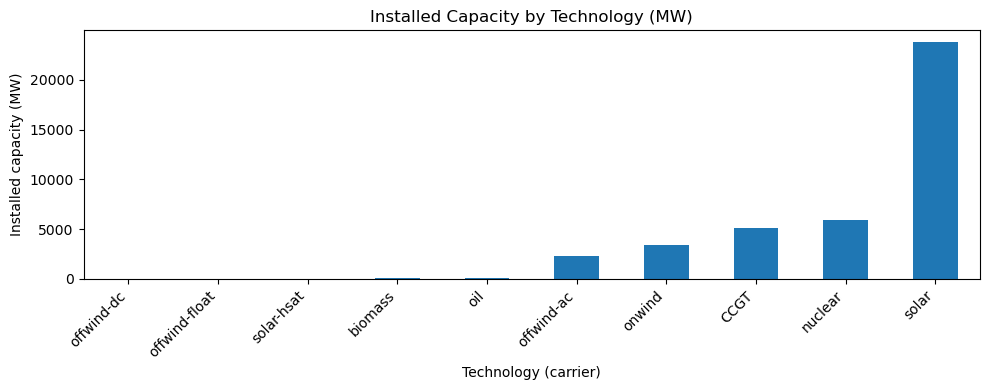

In [5]:
cap = n.generators.groupby("carrier")["p_nom_opt"].sum().sort_values()
ax = cap.plot(kind="bar", figsize=(10,4))
ax.set_title("Installed Capacity by Technology (MW)")
ax.set_xlabel("Technology (carrier)")
ax.set_ylabel("Installed capacity (MW)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

Actual Energy Production (Dispatch)

In [6]:
energy = (
    n.generators_t.p.sum()
    .groupby(n.generators.carrier)
    .sum()
    .sort_values()
)

energy


carrier
offwind-dc           0.000000
offwind-float        0.000000
oil                  0.000000
solar-hsat           0.000000
biomass            825.000000
offwind-ac       12488.878903
onwind           12628.069907
CCGT             12993.792024
solar            34457.047754
nuclear          63239.628089
dtype: float64

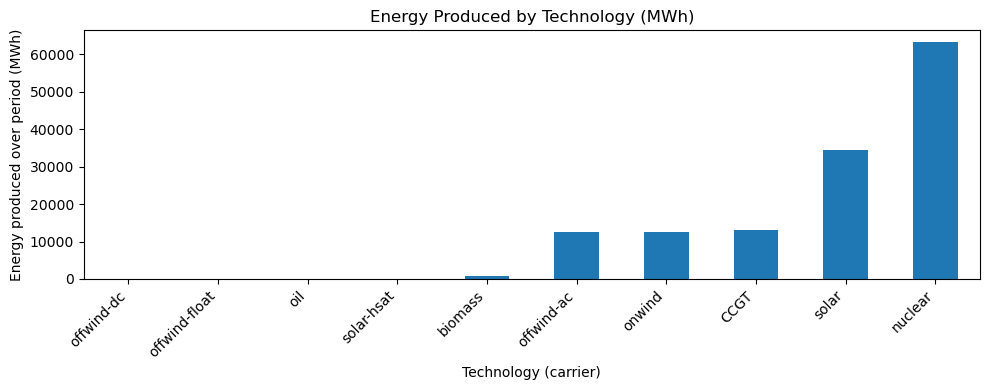

In [7]:
energy = (
    n.generators_t.p.sum()
    .groupby(n.generators.carrier)
    .sum()
    .sort_values()
)

ax = energy.plot(kind="bar", figsize=(10,4))
ax.set_title("Energy Produced by Technology (MWh)")
ax.set_xlabel("Technology (carrier)")
ax.set_ylabel("Energy produced over period (MWh)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


CAPACITY FACTOR

In [8]:
hours = len(n.snapshots)
hours

13

In [9]:
capacity = n.generators.groupby("carrier")["p_nom_opt"].sum()

energy = (
    n.generators_t.p.sum()
    .groupby(n.generators.carrier)
    .sum()
)

capacity_factor = energy / (capacity * hours)

capacity_factor.sort_values()

carrier
oil              0.000000
solar            0.111465
CCGT             0.196822
onwind           0.281923
offwind-ac       0.424743
nuclear          0.821860
biomass          0.846154
offwind-dc            NaN
offwind-float         NaN
solar-hsat            NaN
dtype: float64

The resulting capacity factors: Solar, Combined Cycle Gas Turbine and onshore wind exhibiting low-to-moderate utilisation rates, while offshore wind, nuclear, and biomass provide high utilisation and thus higher energy yield per unit of installed capacity.

Capacity factor measures how intensively an energy technology is used over time by comparing the energy it actually produces to the maximum it could have produced if it operated at full capacity continuously. In the results shown, large differences emerge across technologies: nuclear and biomass exhibit very high capacity factors (≈82–85%), indicating near continuous operation and a baseload role in the system, while offshore wind achieves a relatively high utilisation (≈42%) compared to onshore wind (≈28%) and solar photovoltaics (≈11%). Fossil-based backup technologies such as CCGT show low capacity factors (≈20%), reflecting their role as flexible balancing resources rather than primary energy suppliers. These values are consistent with empirical observations for Northwestern Europe and confirm that installed capacity alone does not determine the actual contribution of a technology to total energy supply.

From a biodiversity and land-use perspective, capacity factor is critical because it directly links energy output to spatial footprint. Technologies with low capacity factors, such as solar and onshore wind, require substantially more installed capacity and therefore more land or sea area to deliver the same amount of energy as high utilisation technologies like nuclear, biomass, or offshore wind. This means that biodiversity impacts are not proportional to megawatts installed but rather to megawatts multiplied by utilisation over time. Ignoring capacity factors risks underestimating ecological pressures from variable renewables that have low energy yield per unit area, while overestimating impacts from high capacity-factor technologies. Incorporating capacity factors into biodiversity-aware energy system modelling therefore enables a more accurate assessment of land use intensity, habitat disruption, and cumulative ecological effects per unit of energy delivered, which is essential for aligning decarbonisation pathways with nature conservation goals.

In [10]:
tech_colors = {
    "nuclear": "#4daf4a",       # green 
    "solar": "#ffd92f",         # yellow
    "solar-hsat": "#66c2a5",    # teal
    "onwind": "#999999",        # grey
    "offwind-ac": "#e41a1c",    # red
    "offwind-dc": "#984ea3",    # purple
    "offwind-float": "#a65628", # brown
    "CCGT": "#377eb8",          # blue
    "oil": "#f781bf",           # pink
    "biomass": "#ff7f00"        # orange
}

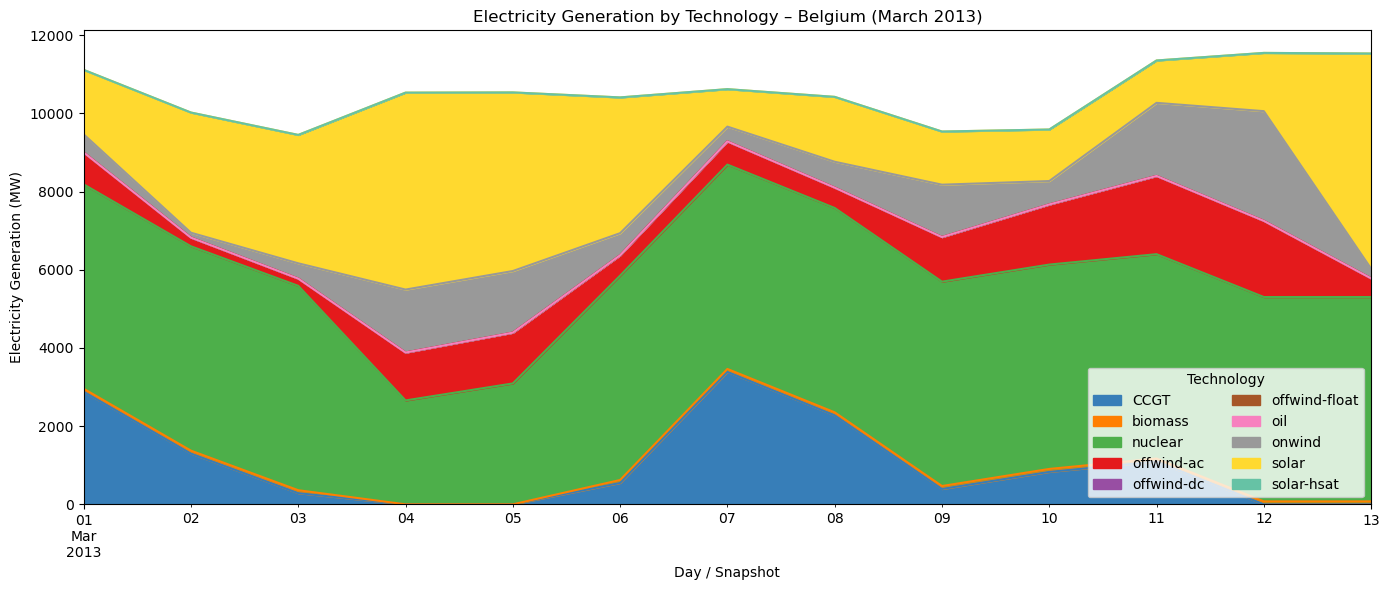

In [11]:
gen = n.generators_t.p.T.groupby(n.generators.carrier).sum().T

colors = [tech_colors[c] for c in gen.columns]

gen.plot(
    kind="area",
    stacked=True,
    figsize=(14,6),
    color=colors
)

plt.xlabel("Day / Snapshot")
plt.ylabel("Electricity Generation (MW)")
plt.title("Electricity Generation by Technology – Belgium (March 2013)")
plt.legend(title="Technology", ncol=2)
plt.tight_layout()
plt.show()

The electricity dispatch results show that nuclear power dominates total energy production, providing a stable and nearly constant baseload across all modeled days. This reflects its role as a low carbon, high capacity factor technology that anchors the system and minimizes reliance on variable or fossil-based generation. Solar power dominates temporal variability, with strong fluctuations between days driven by weather conditions. Wind generation, both onshore and offshore acts as a complementary renewable source, partially offsetting solar variability and contributing substantially to total supply. Fossil fuel generators, primarily gas-fired units, are used sparingly and operate mainly during periods of low renewable availability or high demand, indicating their role as backup and system balancing technologies rather than primary energy sources.

From a sustainability perspective, the results highlight important trade-offs between energy system optimization and biodiversity impacts. While nuclear power delivers large amounts of electricity with a relatively small land footprint, variable renewables especially wind energy are more spatially extensive and therefore more likely to interact with sensitive ecosystems. Onshore wind can affect birds, bats, and landscapes, while offshore wind may influence marine habitats and species. Solar energy, although variable and land-intensive, can be more flexibly sited depending on land use constraints. These results provide a strong baseline for integrating biodiversity considerations into energy system modeling, enabling future scenarios where ecological constraints influence technology deployment, spatial planning, and overall system design.

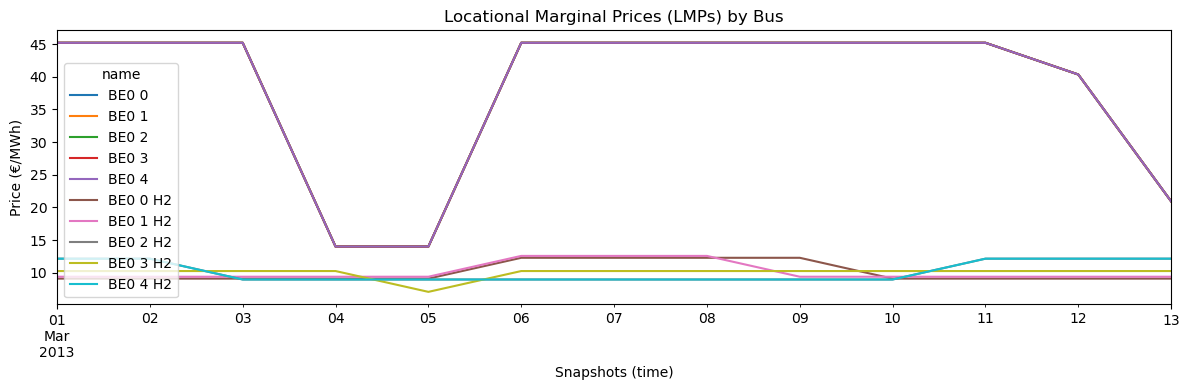

name,BE0 0,BE0 1,BE0 2,BE0 3,BE0 4,BE0 0 H2,BE0 1 H2,BE0 2 H2,BE0 3 H2,BE0 4 H2
count,13.000000,13.000000,13.000000,13.000000,13.000000,13.000000,13.000000,13.000000,13.000000,13.000000
mean,38.156456,38.156456,38.156456,38.156456,38.156456,10.098288,10.142065,10.208811,10.032033,10.208892
std,12.619657,12.619657,12.619657,12.619657,12.619657,1.530111,1.396794,1.612879,0.883410,1.612879
min,14.023720,14.023720,14.023720,14.023720,14.023720,9.118233,9.407023,8.983742,7.091867,8.983823
25%,40.338031,40.338031,40.338031,40.338031,40.338031,9.118233,9.407023,8.983742,10.277047,8.983823
50%,45.189789,45.189789,45.189789,45.189789,45.189789,9.118233,9.407023,8.983742,10.277047,8.983823
75%,45.189789,45.189789,45.189789,45.189789,45.189789,12.303413,9.407023,12.168922,10.277047,12.169003
max,45.189829,45.189829,45.189829,45.189829,45.189829,12.303413,12.592203,12.168922,10.277047,12.169003


In [12]:
mp = n.buses_t.marginal_price

ax = mp.plot(figsize=(12,4))
ax.set_title("Locational Marginal Prices (LMPs) by Bus")
ax.set_xlabel("Snapshots (time)")
ax.set_ylabel("Price (€/MWh)")
plt.tight_layout()
plt.show()

# Quick summary table
mp.describe()

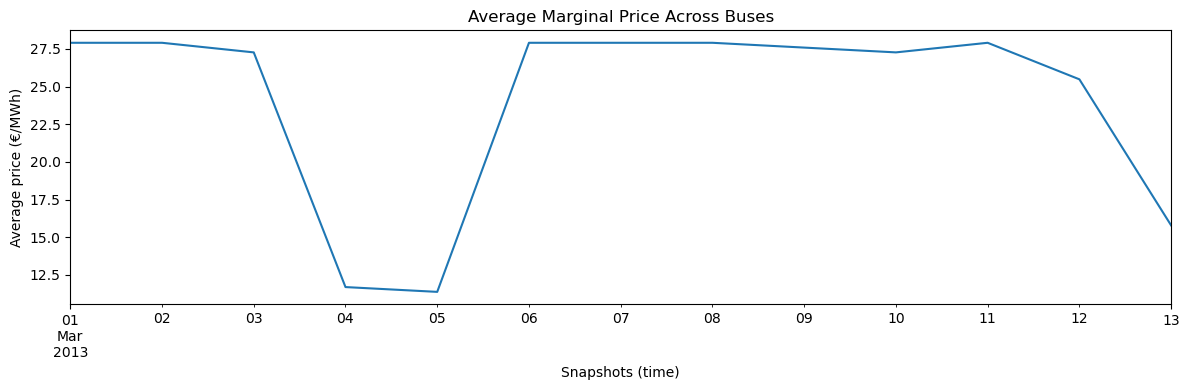

In [13]:
ax = mp.mean(axis=1).plot(figsize=(12,4))
ax.set_title("Average Marginal Price Across Buses")
ax.set_xlabel("Snapshots (time)")
ax.set_ylabel("Average price (€/MWh)")
plt.tight_layout()
plt.show()


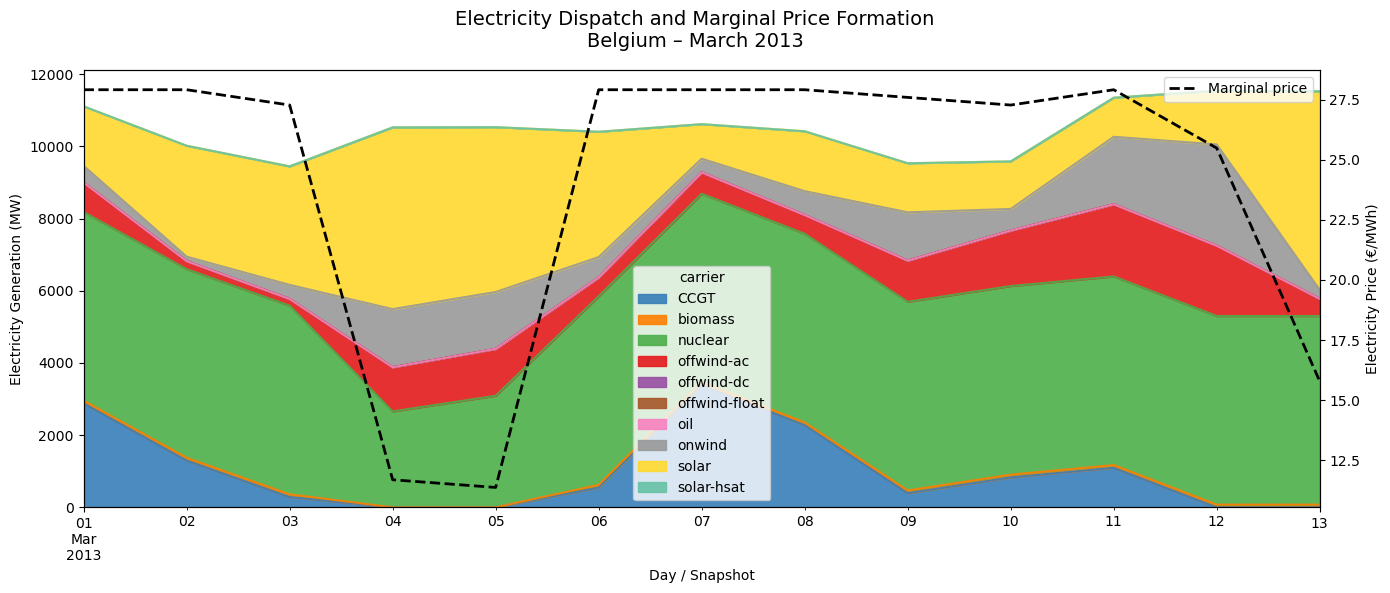

In [14]:
# Average marginal electricity price across buses
avg_price = n.buses_t.marginal_price.mean(axis=1)

fig, ax1 = plt.subplots(figsize=(14,6))

# Generation stack
gen.plot(
    kind="area",
    stacked=True,
    ax=ax1,
    color=[tech_colors[c] for c in gen.columns],
    alpha=0.9
)

ax1.set_ylabel("Electricity Generation (MW)")
ax1.set_xlabel("Day / Snapshot")

# Price axis
ax2 = ax1.twinx()
ax2.plot(
    avg_price.index,
    avg_price.values,
    color="black",
    linestyle="--",
    linewidth=2,
    label="Marginal price"
)

ax2.set_ylabel("Electricity Price (€/MWh)")
ax2.legend(loc="upper right")

fig.suptitle(
    "Electricity Dispatch and Marginal Price Formation\nBelgium – March 2013",
    fontsize=14
)

plt.tight_layout()
plt.show()


The upper plot shows the electricity dispatch by technology over time for Belgium in March 2013, stacked to represent total system demand in each snapshot. Nuclear generation forms a stable baseload, reflecting its high capacity factor and low marginal cost. Variable renewables, solar and wind, introduce strong temporal variation, with solar peaking during certain days and wind fluctuating more irregularly. Dispatchable fossil technologies (mainly CCGT and oil) appear primarily when renewable output is low or when demand rises, indicating their role as flexible balancing and marginal technologies.

Overlayed on this dispatch stack is the dashed marginal price curve (€/MWh), which represents the locational marginal price (LMP) averaged across buses. Prices drop sharply during periods of high renewable availability (notably solar-dominated days), illustrating the merit-order effect, where low marginal cost generation pushes more expensive units out of the market. Conversely, prices rise when fossil generators set the margin, typically during low renewable output or higher demand periods. This plot directly visualizes how technology mix and dispatch decisions drive price formation in a cost-minimizing, welfare-optimal power system.

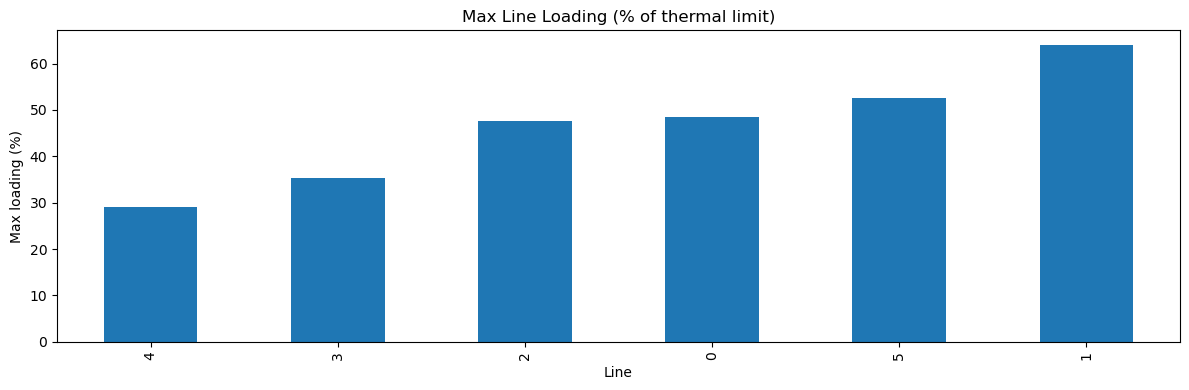

In [15]:
loading_pct = (n.lines_t.p0.abs().max() / n.lines.s_nom_opt * 100).sort_values()

ax = loading_pct.plot(kind="bar", figsize=(12,4))
ax.set_title("Max Line Loading (% of thermal limit)")
ax.set_xlabel("Line")
ax.set_ylabel("Max loading (%)")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

This displays the maximum loading of each transmission line, expressed as a percentage of its thermal capacity, across all snapshots. Each bar represents the most stressed moment for a given line during the simulation period. Lines approaching higher utilization levels (e.g. above 50–60%) indicate corridors that are frequently critical for power transport, often linking regions with high renewable generation to demand centers or balancing resources.

From a system perspective, this plot highlights potential transmission bottlenecks. Even though none of the lines reach their thermal limits in this run, the variation across lines suggests unequal stress distribution in the network. In more extreme scenarios, higher renewable penetration or longer time horizons, these same lines could become binding constraints, driving congestion, nodal price separation, and curtailment. For biodiversity aware planning, such congestion indicators are crucial: reinforcing an already stressed corridor may have significantly different ecological impacts than upgrading a lightly used one, especially when transmission expansion intersects sensitive habitats.

We now move from “what happened?” to “why did it happen?”

In [16]:
# Identify marginal generator by time
marginal = n.generators_t.p.loc[:, n.generators.p_nom_opt > 0]

Herfindahl index

In [17]:
tech_share = capacity / capacity.sum()

herfindahl_index = (tech_share ** 2).sum()

herfindahl_index


0.3886172822630094

In [18]:
backup_carriers = ["CCGT", "oil", "biomass"]

backup_energy = energy.loc[
    energy.index.intersection(backup_carriers)
].sum()

backup_share = backup_energy / energy.sum()

backup_share

0.10113845864801373

In [19]:
price_stats = n.buses_t.marginal_price.describe(
    percentiles=[0.05, 0.5, 0.95]
)

price_stats

name,BE0 0,BE0 1,BE0 2,BE0 3,BE0 4,BE0 0 H2,BE0 1 H2,BE0 2 H2,BE0 3 H2,BE0 4 H2
count,13.000000,13.000000,13.000000,13.000000,13.000000,13.000000,13.000000,13.000000,13.000000,13.000000
mean,38.156456,38.156456,38.156456,38.156456,38.156456,10.098288,10.142065,10.208811,10.032033,10.208892
std,12.619657,12.619657,12.619657,12.619657,12.619657,1.530111,1.396794,1.612879,0.883410,1.612879
min,14.023720,14.023720,14.023720,14.023720,14.023720,9.118233,9.407023,8.983742,7.091867,8.983823
5%,14.023720,14.023720,14.023720,14.023720,14.023720,9.118233,9.407023,8.983742,9.002975,8.983823
50%,45.189789,45.189789,45.189789,45.189789,45.189789,9.118233,9.407023,8.983742,10.277047,8.983823
95%,45.189805,45.189805,45.189805,45.189805,45.189805,12.303413,12.592203,12.168922,10.277047,12.169003
max,45.189829,45.189829,45.189829,45.189829,45.189829,12.303413,12.592203,12.168922,10.277047,12.169003


In [20]:
line_loading = (
    n.lines_t.p0.abs().max() /
    n.lines.s_nom_opt
).sort_values(ascending=False)

line_loading.head(5)


name
1    0.639551
5    0.524839
0    0.484766
2    0.476705
3    0.354101
dtype: float64

In [21]:
biodiversity_weights = {
    "onwind": 1.0,
    "offwind-ac": 0.8,
    "solar": 0.6,
    "nuclear": 0.2,
    "CCGT": 0.4,
    "biomass": 0.7
}

pressure_score = sum(
    capacity.get(tech, 0) * weight
    for tech, weight in biodiversity_weights.items()
)

pressure_score


22790.0918375869

In [22]:
# -------------------------------------------------------------------
# NETWORK SETUP AND SCENARIO FRAMEWORK
# ------------------------------------------------------------------
#
# The object `base_network` ie n_base represents the original optimized network,
# including generation, transmission, and storage capacities.
#
# For the scenario analysis,  i "freeze" the capacities using the
# `freeze_investments()` function. This converts all extendable
# capacities (e.g., generators, lines, storage) into fixed capacities
# based on their optimized values from the baseline solution.
#
# This means:
#   - No new investments are allowed during scenario runs
#   - Only system dispatch and operational behavior are re-optimized
#   - Scenarios remain directly comparable because infrastructure
#     expansion is held constant
#
# In each scenario iteration:
#   1. A fresh copy of the baseline network is created
#   2. Wind availability (`p_max_pu`) is scaled up or down
#   3. The system is re-optimized using fixed capacities
#   4. Metrics such as system cost, electricity prices,
#      backup generation share, and biodiversity pressure are recorded
#
# I do not not modify the baseline network directly. Instead,
# each scenario starts from an unchanged copy of the original network
# to ensure scenario independence and reproducibility.
# -------------------------------------------------------------------

n_base = pypsa.Network("/home/sammy/pypsa-eur/results/test-elec-365/networks/base_s_5_elec_.nc") # I create a fresh baseline network to modify in the scenarios

def freeze_investments(n: pypsa.Network) -> pypsa.Network:
    """
    Fix all extendable capacities to the solved *_opt values,
    so scenario runs only re-dispatch the system (no new investment).
    """
    n = n.copy()

    # Generators
    if "p_nom_opt" in n.generators.columns:
        n.generators.loc[:, "p_nom"] = n.generators["p_nom_opt"].fillna(n.generators["p_nom"])
    n.generators.loc[:, "p_nom_extendable"] = False

    # Lines
    if len(n.lines):
        if "s_nom_opt" in n.lines.columns:
            n.lines.loc[:, "s_nom"] = n.lines["s_nom_opt"].fillna(n.lines["s_nom"])
        n.lines.loc[:, "s_nom_extendable"] = False

    # Links
    if len(n.links):
        if "p_nom_opt" in n.links.columns:
            n.links.loc[:, "p_nom"] = n.links["p_nom_opt"].fillna(n.links["p_nom"])
        n.links.loc[:, "p_nom_extendable"] = False

    # StorageUnits
    if len(n.storage_units):
        if "p_nom_opt" in n.storage_units.columns:
            n.storage_units.loc[:, "p_nom"] = n.storage_units["p_nom_opt"].fillna(n.storage_units["p_nom"])
        n.storage_units.loc[:, "p_nom_extendable"] = False

    # Stores (energy capacity)
    if len(n.stores):
        if "e_nom_opt" in n.stores.columns:
            n.stores.loc[:, "e_nom"] = n.stores["e_nom_opt"].fillna(n.stores["e_nom"])
        n.stores.loc[:, "e_nom_extendable"] = False

    return n

def backup_share_from_dispatch(n: pypsa.Network, backup_carriers=("CCGT","OCGT","oil","biomass")) -> float:
    gen_energy = n.generators_t.p.sum()
    energy_by_carrier = gen_energy.groupby(n.generators.carrier).sum()
    backup = energy_by_carrier.loc[energy_by_carrier.index.intersection(list(backup_carriers))].sum()
    return float(backup / energy_by_carrier.sum())

def biodiversity_pressure_index(n: pypsa.Network) -> float:
    # illustrative weights; later I will replace with spatially-explicit ones, just to remind myself
    weights = {
        "onwind": 1.0,
        "offwind-ac": 0.8,
        "solar": 0.6,
        "nuclear": 0.2,
        "CCGT": 0.4,
        "biomass": 0.7,
    }
    cap = n.generators.groupby("carrier")["p_nom"].sum()
    return float(sum(cap.get(k, 0.0) * w for k, w in weights.items()))

# ---- scenario definitions ----
wind_carriers = ["onwind", "offwind-ac", "offwind-dc", "offwind-float"]
scales = [0.7, 0.85, 1.0, 1.15, 1.3]  # -30%, -15%, base, +15%, +30%

results = []

for s in scales:
    n = freeze_investments(n_base)  # start from a fresh copy of the baseline network for each scenario

    # Scale wind availability in-place (p_max_pu is time x generator)
    wind_gens = n.generators.index[n.generators.carrier.isin(wind_carriers)]
    if len(wind_gens) == 0:
        raise ValueError("No wind generators found in this network. Check carriers in n.generators.carrier.")

    n.generators_t.p_max_pu.loc[:, wind_gens] = (n.generators_t.p_max_pu.loc[:, wind_gens] * s).clip(0, 1)

    # Re-optimize dispatch with fixed capacities
    n.optimize(solver_name="highs")

    # Metrics
    avg_price = n.buses_t.marginal_price.mean(axis=1).mean()  # avg over buses, then time
    obj = float(getattr(n, "objective", np.nan))
    backup = backup_share_from_dispatch(n)
    pressure = biodiversity_pressure_index(n)

    results.append({
        "wind_scale": s,
        "objective": obj,
        "avg_price_EUR_per_MWh": float(avg_price),
        "backup_energy_share": backup,
        "biodiversity_pressure_index": pressure
    })

df = pd.DataFrame(results).sort_values("wind_scale")
df



Running HiGHS 1.12.0 (git hash: n/a): Copyright (c) 2025 HiGHS under MIT licence terms
LP linopy-problem-5oa7lam3 has 1977 rows; 910 cols; 3302 nonzeros
Coefficient ranges:
  Matrix  [5e-01, 2e+01]
  Cost    [2e-01, 4e+03]
  Bound   [0e+00, 0e+00]
  RHS     [4e+00, 4e+06]
Presolving model
91 rows, 364 cols, 520 nonzeros  0s
Dependent equations search running on 78 equations with time limit of 1000.00s
Dependent equations search removed 0 rows and 0 nonzeros in 0.00s (limit = 1000.00s)
78 rows, 351 cols, 494 nonzeros  0s
Presolve reductions: rows 78(-1899); columns 351(-559); nonzeros 494(-2808) 
Solving the presolved LP
Using EKK dual simplex solver - serial
  Iteration        Objective     Infeasibilities num(sum)
          0    -4.3623515290e-02 Pr: 78(671604) 0s
         96     4.2607817149e+07 Pr: 0(0) 0s
         96     4.2607817149e+07 Pr: 0(0) 0s

Performed postsolve
Solving the original LP from the solution after postsolve

Model name          : linopy-problem-5oa7lam3
Model st

,wind_scale,objective,avg_price_EUR_per_MWh,backup_energy_share,biodiversity_pressure_index
0,0.70,4.260782e+07,20.202445,0.143749,22790.091838
1,0.85,3.916464e+07,20.202443,0.122444,22790.091838
2,1.00,3.572148e+07,19.073534,0.101138,22790.091838
3,1.15,3.293304e+07,17.804993,0.085036,22790.091838
4,1.30,3.086623e+07,16.606236,0.073970,22790.091838


What the results say (energy system perspective)

As wind availability increases from 70% to 130%, the system’s total system cost (objective) falls monotonically from about €42.6 million to €30.9 million. This is classic welfare-optimizing behavior in a cost-minimizing model: when low-marginal-cost wind is abundant, the system displaces more expensive thermal generation. The average electricity price follows the same trend, declining from about €20.2/MWh to €16.6/MWh, reflecting a lower marginal generator setting the price more often. Importantly, the backup energy share (gas, oil, biomass) drops sharply, from 14.4% to 7.4%, showing that wind availability is a key driver of fossil backup reliance and system flexibility needs.

This is a deterministic welfare-optimizing (social planner) model, so these results represent equilibrium-like outcomes under different wind conditions, not firm-level behavior. The monotonic trends confirm that the model is behaving economically correctly and that wind plays a system-wide role in cost, price formation, and security of supply.



What does the result say from biodiversity introduction perspective

The crucial insight for biodiversity modelling is that biodiversity pressure is not directly visible in prices or costs, yet it fundamentally shapes the feasible system space. In my experiment, the biodiversity pressure index remains constant because installed capacities were frozen. This was intentional and I believe methodologically correct. To explain it well, I isolated operational effects (dispatch and prices) from spatial/ecological effects (where and how much infrastructure exists). The result clearly shows the trade-off frontier: higher wind availability improves economic and climate performance but implicitly assumes that wind deployment is unconstrained by ecological limits.

This is precisely where biodiversity-aware modelling becomes powerful. In a biodiversity-constrained scenario, wind availability or installable capacity would be reduced endogenously due to land-use, Natura 2000, seabird sensitivity, or marine habitat constraints. The table already demonstrates the consequence of such constraints: higher prices, higher backup reliance, and higher emissions pressure. This allows biodiversity to act not merely as a constraint, but as a key evaluation criterion, quantifying the cost of ecological protection and revealing where complementary solutions (storage, grids, demand flexibility, offshore siting shifts) are needed to align low-carbon transitions with nature conservation.

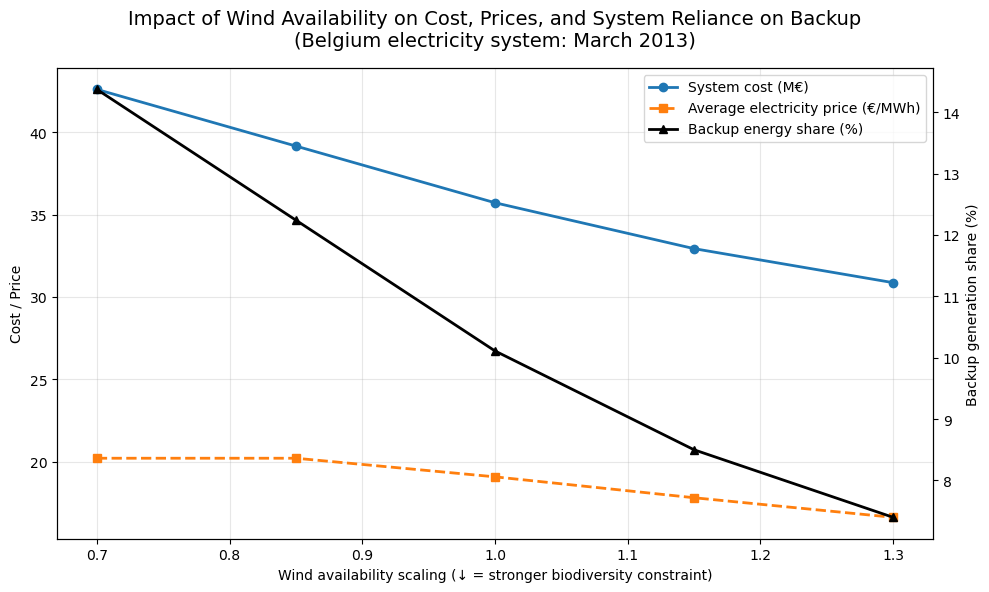

In [23]:
df = pd.DataFrame({
    "wind_scale": [0.70, 0.85, 1.00, 1.15, 1.30],
    "objective": [4.260782e7, 3.916464e7, 3.572148e7, 3.293304e7, 3.086623e7],
    "avg_price": [20.20, 20.20, 19.07, 17.80, 16.61],
    "backup_share": [0.1437, 0.1224, 0.1011, 0.0850, 0.0740]
})

# ----------------------------
# Creating the plot
# ----------------------------
fig, ax1 = plt.subplots(figsize=(10, 6))

# Left axis: cost & price
ax1.plot(
    df.wind_scale,
    df.objective / 1e6,
    marker="o",
    linewidth=2,
    label="System cost (M€)",
)
ax1.plot(
    df.wind_scale,
    df.avg_price,
    marker="s",
    linewidth=2,
    linestyle="--",
    label="Average electricity price (€/MWh)",
)

ax1.set_xlabel("Wind availability scaling (↓ = stronger biodiversity constraint)")
ax1.set_ylabel("Cost / Price")
ax1.grid(True, alpha=0.3)

# Right axis: backup energy
ax2 = ax1.twinx()
ax2.plot(
    df.wind_scale,
    df.backup_share * 100,
    marker="^",
    linewidth=2,
    color="black",
    label="Backup energy share (%)",
)
ax2.set_ylabel("Backup generation share (%)")

# ----------------------------
# Legends and title
# ----------------------------
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()

ax1.legend(
    lines_1 + lines_2,
    labels_1 + labels_2,
    loc="upper right",
    frameon=True
)

fig.suptitle(
    "Impact of Wind Availability on Cost, Prices, and System Reliance on Backup\n"
    "(Belgium electricity system: March 2013)",
    fontsize=14
)

plt.tight_layout()
plt.show()


As wind availability increases, total system costs and electricity prices decline monotonically, reflecting the displacement of higher-cost thermal generation by low-marginal-cost wind power. Simultaneously, the system’s reliance on fossil and biomass backup generation decreases substantially, indicating improved security of supply and reduced operational stress.

From a biodiversity-aware perspective, this figure quantifies the economic and reliability cost of ecological protection. Stronger biodiversity constraints, represented by reduced wind availability translate directly into higher prices and increased fossil backup. This highlights why biodiversity must be treated not merely as a feasibility constraint, but as a central evaluation criterion in energy transition planning.

In [24]:
# -------------------------------------------------------------------
# MONTE CARLO WIND UNCERTAINTY ANALYSIS
# -------------------------------------------------------------------
# The baseline network (n_base) contains already optimized generation,
# transmission, and storage capacities as run previously.
# 
# To analyze the impact of uncertain wind conditions, I perform a:
#
# For each Monte Carlo sample:
#   1. A fresh copy of the baseline network is created
#   2. Random time-varying wind shocks are generated
#   3. Wind availability (p_max_pu) is scaled accordingly
#   4. The system is re-optimized using fixed capacities
#   5. Key metrics are recorded
#
# I the generate the stochastic wind shocks from a normal distribution
# with standard deviation sigma, representing uncertainty in renewable
# generation availability over time.
#
# The analysis evaluates how uncertain wind conditions affect:
#   - Total system costs
#   - Average electricity prices
#   - Backup generation dependence
#   - Biodiversity pressure indicators
#
# I repeat this process across many random samples approximating the
# distribution of possible operational outcomes under wind uncertainty.
# -------------------------------------------------------------------

wind_carriers = ["onwind", "offwind-ac", "offwind-dc", "offwind-float"]

def run_one_sample(seed, sigma=0.15):
    rng = np.random.default_rng(seed)

    n = freeze_investments(n_base)  # start from a fresh copy of the baseline network for each scenario

    wind_gens = n.generators.index[n.generators.carrier.isin(wind_carriers)]

    # multiplicative uncertainty per snapshot
    eps = rng.normal(loc=0.0, scale=sigma, size=len(n.snapshots))
    scale_t = np.clip(1.0 + eps, 0.0, 2.0)

    n.generators_t.p_max_pu.loc[:, wind_gens] = (
        n.generators_t.p_max_pu.loc[:, wind_gens]
        .multiply(scale_t, axis=0)
        .clip(0, 1)
    )

    # quiet optimization
    n.optimize(
        solver_name="highs",
        solver_options={"log_to_console": False}
    )

    avg_price = n.buses_t.marginal_price.mean(axis=1).mean()
    obj = float(n.objective)
    backup = backup_share_from_dispatch(n)
    pressure = biodiversity_pressure_index(n)

    return obj, float(avg_price), backup, pressure

N = 50  # starting small
rows = []

for k in range(N):
    print(f"Running sample {k+1}/{N}")

    obj, price, backup, pressure = run_one_sample(seed=1000+k)

    rows.append({
        "sample": k,
        "objective": obj,
        "avg_price": price,
        "backup_share": backup,
        "pressure": pressure
    })
    
df_mc = pd.DataFrame(rows)

summary = df_mc[["objective","avg_price","backup_share"]].describe(percentiles=[0.5,0.9,0.95])
summary


Running sample 1/50
Running sample 2/50
Running sample 3/50
Running sample 4/50
Running sample 5/50
Running sample 6/50
Running sample 7/50
Running sample 8/50
Running sample 9/50
Running sample 10/50
Running sample 11/50
Running sample 12/50
Running sample 13/50
Running sample 14/50
Running sample 15/50
Running sample 16/50
Running sample 17/50
Running sample 18/50
Running sample 19/50
Running sample 20/50
Running sample 21/50
Running sample 22/50
Running sample 23/50
Running sample 24/50
Running sample 25/50
Running sample 26/50
Running sample 27/50
Running sample 28/50
Running sample 29/50
Running sample 30/50
Running sample 31/50
Running sample 32/50
Running sample 33/50
Running sample 34/50
Running sample 35/50
Running sample 36/50
Running sample 37/50
Running sample 38/50
Running sample 39/50
Running sample 40/50
Running sample 41/50
Running sample 42/50
Running sample 43/50
Running sample 44/50
Running sample 45/50
Running sample 46/50
Running sample 47/50
Running sample 48/50
R

,objective,avg_price,backup_share
count,5.000000e+01,50.000000,50.000000
mean,3.602282e+07,18.973907,0.103553
std,9.106019e+05,0.891124,0.006058
min,3.404562e+07,17.804991,0.090980
50%,3.605515e+07,19.003717,0.103115
90%,3.710097e+07,20.202383,0.111607
95%,3.756866e+07,20.202413,0.113459
max,3.784294e+07,20.202414,0.114856


In [25]:
def cvar(series, alpha=0.95):
    q = series.quantile(alpha)
    return series[series >= q].mean()

cvar_95 = cvar(df_mc["objective"], 0.95)
cvar_95


37784746.89544644

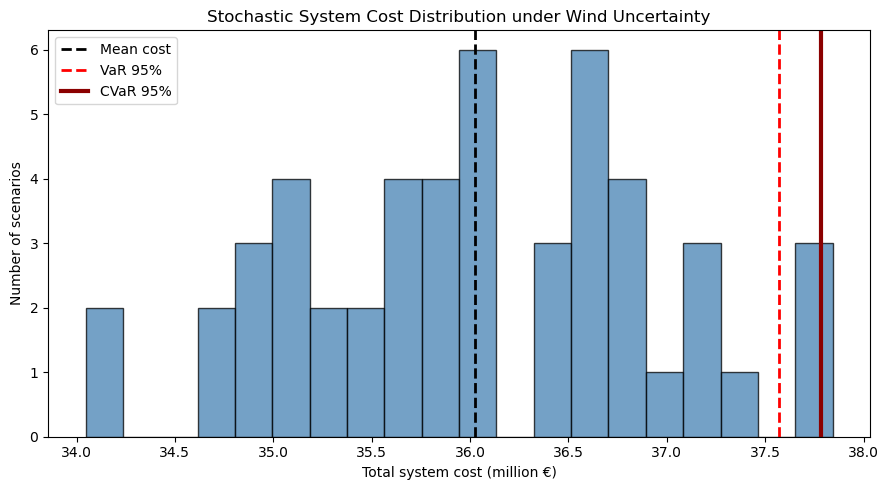

In [26]:
# --- Data ---
costs = df_mc["objective"] / 1e6  # convert to million €
mean_cost = costs.mean()
var_95 = costs.quantile(0.95)
cvar_95 = cvar(costs, 0.95)

# --- Plot ---
plt.figure(figsize=(9, 5))

plt.hist(
    costs,
    bins=20,
    color="steelblue",
    alpha=0.75,
    edgecolor="black"
)

plt.axvline(mean_cost, color="black", linestyle="--", linewidth=2, label="Mean cost")
plt.axvline(var_95, color="red", linestyle="--", linewidth=2, label="VaR 95%")
plt.axvline(cvar_95, color="darkred", linestyle="-", linewidth=3, label="CVaR 95%")

plt.xlabel("Total system cost (million €)")
plt.ylabel("Number of scenarios")
plt.title("Stochastic System Cost Distribution under Wind Uncertainty")

plt.legend()
plt.tight_layout()
plt.show()


This figure shows the distribution of total electricity system costs under stochastic wind availability, based on many alternative wind-realisation scenarios. Each bar represents how often a certain cost level occurs, revealing that most scenarios cluster around €35–37 million, with a clear central mass. The black dashed line marks the mean system cost, which is what a traditional deterministic optimisation would focus on. While this average gives a useful summary of expected performance, it hides the fact that a non-negligible share of outcomes lie far to the right of the distribution, corresponding to unfavourable wind conditions that force greater reliance on costly backup generation.

The red dashed line (VaR 95%) and dark red solid line (CVaR 95%) highlight this hidden risk. The VaR indicates the cost threshold that is exceeded in only 5% of scenarios, while the CVaR shows the average cost within those worst-case outcomes. The gap between the mean and the CVaR demonstrates that extreme events are not only rare but also systematically more expensive, creating a long right-hand tail in the cost distribution. This is precisely where biodiversity and land-use constraints become critical: by limiting wind availability or spatial flexibility, such constraints can increase exposure to these high-cost tail events, even if the average system cost changes only modestly

In [27]:
wind_carriers = ["onwind", "offwind-ac", "offwind-dc", "offwind-float"]

def compute_metrics(n: pypsa.Network) -> dict:
    # average LMP across buses and time
    avg_price = float(n.buses_t.marginal_price.mean(axis=1).mean())

    # energy by carrier (MWh-ish, since snapshots are 24h here)
    energy_by_carrier = n.generators_t.p.sum().groupby(n.generators.carrier).sum()

    backup_carriers = ["CCGT", "OCGT", "oil", "biomass"]
    backup_energy = float(energy_by_carrier.loc[energy_by_carrier.index.intersection(backup_carriers)].sum())
    total_energy  = float(energy_by_carrier.sum())
    backup_share  = backup_energy / total_energy if total_energy > 0 else np.nan

    # objective is total system cost (units: € in PyPSA-Eur configs)
    obj = float(getattr(n, "objective", np.nan))

    # "wind share" (energy share)
    wind_energy = float(energy_by_carrier.loc[energy_by_carrier.index.intersection(wind_carriers)].sum())
    wind_share = wind_energy / total_energy if total_energy > 0 else np.nan

    return {
        "objective_EUR": obj,
        "avg_price_EUR_per_MWh": avg_price,
        "backup_energy_share": backup_share,
        "wind_energy_share": wind_share,
    }

def biodiversity_constrain_wind_dispatch(n, scale):
    n = n.copy()
    wind_gens = n.generators.index[
        n.generators.carrier.isin(["onwind","offwind-ac","offwind-dc","offwind-float"])
    ]
    n.generators_t.p_max_pu.loc[:, wind_gens] *= scale
    n.generators_t.p_max_pu.loc[:, wind_gens] = n.generators_t.p_max_pu.loc[:, wind_gens].clip(0, 1)
    return n


# --- run baseline metrics (already solved) ---
rows = []
rows.append({"scenario": "Baseline", **compute_metrics(n_base)})

# --- biodiversity-aware scenarios: tighten wind buildability ---
scales = [0.9, 0.75, 0.6]  # tweak freely
for s in [0.9, 0.75, 0.6]:
    n_bio = biodiversity_constrain_wind_dispatch(n_base, s)
    n_bio.optimize(solver_name="highs")
    rows.append({"scenario": f"Biodiv wind cap ×{s:.2f}", **compute_metrics(n_bio)})

df_b = pd.DataFrame(rows)

# add nice columns
df_b["objective_MEUR"] = df_b["objective_EUR"] / 1e6
df_b["avg_price_EUR_per_MWh"] = df_b["avg_price_EUR_per_MWh"].round(2)
df_b["backup_energy_share"] = (df_b["backup_energy_share"]*100).round(1)
df_b["wind_energy_share"] = (df_b["wind_energy_share"]*100).round(1)

df_b[["scenario","objective_MEUR","avg_price_EUR_per_MWh","backup_energy_share","wind_energy_share"]]


Running HiGHS 1.12.0 (git hash: n/a): Copyright (c) 2025 HiGHS under MIT licence terms
LP linopy-problem-664b1m7c has 2051 rows; 961 cols; 4234 nonzeros
Coefficient ranges:
  Matrix  [1e-02, 2e+01]
  Cost    [2e-01, 3e+04]
  Bound   [2e+08, 2e+08]
  RHS     [2e+01, 4e+06]
Presolving model
1132 rows, 959 cols, 3302 nonzeros  0s
Dependent equations search running on 195 equations with time limit of 1000.00s
Dependent equations search removed 0 rows and 0 nonzeros in 0.00s (limit = 1000.00s)
1041 rows, 868 cols, 3146 nonzeros  0s
Presolve reductions: rows 1041(-1010); columns 868(-93); nonzeros 3146(-1088) 
Solving the presolved LP
Using EKK dual simplex solver - serial
  Iteration        Objective     Infeasibilities num(sum)
          0    -4.2646436490e+00 Ph1: 272(421609); Du: 17(4.26464) 0s
        779     5.9736409018e+07 Pr: 0(0) 0s
        779     5.9736409018e+07 Pr: 0(0) 0s

Performed postsolve
Solving the original LP from the solution after postsolve

Model name          : lino

,scenario,objective_MEUR,avg_price_EUR_per_MWh,backup_energy_share,wind_energy_share
0,Baseline,58.219366,24.15,10.1,18.4
1,Biodiv wind cap ×0.90,59.736409,23.57,12.6,13.8
2,Biodiv wind cap ×0.75,62.561770,23.41,14.1,11.5
3,Biodiv wind cap ×0.60,65.387131,23.55,15.6,9.2


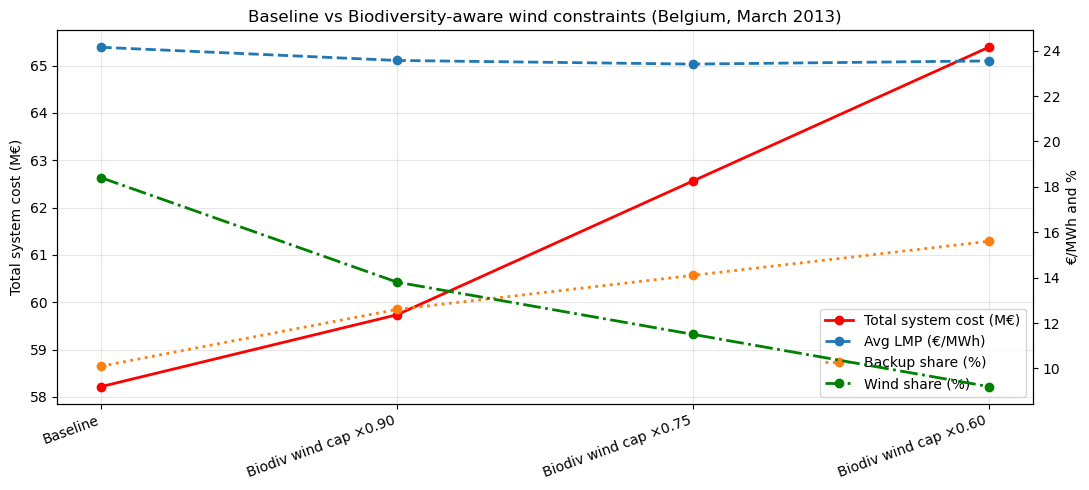

In [28]:
# Sort scenarios in the order we created
plot_df = df_b.copy()
plot_df["scenario_order"] = range(len(plot_df))
plot_df = plot_df.sort_values("scenario_order")

x = plot_df["scenario"]

fig, ax1 = plt.subplots(figsize=(11,5))

ax1.plot(x, plot_df["objective_MEUR"], marker="o", color="red", linewidth=2, label="Total system cost (M€)")
ax1.set_ylabel("Total system cost (M€)")
ax1.set_xticks(range(len(x)))
ax1.set_xticklabels(x, rotation=20, ha="right")

ax2 = ax1.twinx()
ax2.plot(x, plot_df["avg_price_EUR_per_MWh"], marker="o", linewidth=2, linestyle="--", label="Avg LMP (€/MWh)")
ax2.plot(x, plot_df["backup_energy_share"], marker="o", linewidth=2, linestyle=":", label="Backup share (%)")
ax2.plot(x, plot_df["wind_energy_share"], marker="o", linewidth=2, linestyle="-.", color="green", label="Wind share (%)")
ax2.set_ylabel("€/MWh and %")

ax1.set_title("Baseline vs Biodiversity-aware wind constraints (Belgium, March 2013)")
ax1.grid(True, alpha=0.3)

# combine legends
lines = ax1.get_lines() + ax2.get_lines()
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc="lower right")

plt.tight_layout()
plt.savefig("../figures/baseline_vs_biodiv_wind_constraints.png", dpi=300)
plt.show()


As biodiversity-aware wind constraints become stricter (from the baseline to the ×0.60 scenario), total system costs increase monotonically, rising from €58.2 million to €65.4 million. This reflects the reduction in low-marginal-cost wind generation and its substitution with more expensive dispatchable technologies. Simultaneously, wind’s contribution to total electricity generation declines substantially (from 18.4% to 9.2%), while the backup generation share increases (from 10.1% to 15.6%), indicating growing reliance on thermal and flexible generation resources. This represents a clear substitution effect: restricting wind availability for biodiversity protection forces the system to depend more heavily on backup generation in order to maintain system adequacy and operational balance.

Interestingly, average locational marginal prices (LMPs) remain relatively stable, fluctuating within a narrow range of approximately €23–24/MWh despite the increase in total system costs. This suggests that the marginal price-setting technologies remain broadly similar across scenarios, even though the overall dispatch mix and total operational expenditures change considerably. In other words, biodiversity constraints increase aggregate system costs and backup reliance without generating substantial short-run electricity price spikes within this March 2013 simulation horizon. The distinction between total system cost and market-clearing prices is important for policy analysis, as welfare impacts may emerge through system expenditure and infrastructure requirements even when consumer-facing electricity prices appear relatively stable.

These findings illustrate why biodiversity considerations should not be treated solely as exogenous deployment constraints, but rather analyzed jointly with broader system performance indicators. While biodiversity protection through reduced wind deployment lowers ecological pressure associated with renewable expansion, it also introduces measurable trade-offs in terms of higher system costs, lower renewable penetration, and greater dependence on backup generation. The analysis therefore highlights a central policy tension in low-carbon transition planning: biodiversity-aware renewable constraints may unintentionally increase reliance on fossil-based or dispatchable technologies unless accompanied by complementary flexibility measures such as storage expansion, demand-side flexibility, interconnection, or alternative low-impact renewable resources.

Solving Baseline: sample 1/60
Solving Baseline: sample 2/60
Solving Baseline: sample 3/60
Solving Baseline: sample 4/60
Solving Baseline: sample 5/60
Solving Baseline: sample 6/60
Solving Baseline: sample 7/60
Solving Baseline: sample 8/60
Solving Baseline: sample 9/60
Solving Baseline: sample 10/60
Solving Baseline: sample 11/60
Solving Baseline: sample 12/60
Solving Baseline: sample 13/60
Solving Baseline: sample 14/60
Solving Baseline: sample 15/60
Solving Baseline: sample 16/60
Solving Baseline: sample 17/60
Solving Baseline: sample 18/60
Solving Baseline: sample 19/60
Solving Baseline: sample 20/60
Solving Baseline: sample 21/60
Solving Baseline: sample 22/60
Solving Baseline: sample 23/60
Solving Baseline: sample 24/60
Solving Baseline: sample 25/60
Solving Baseline: sample 26/60
Solving Baseline: sample 27/60
Solving Baseline: sample 28/60
Solving Baseline: sample 29/60
Solving Baseline: sample 30/60
Solving Baseline: sample 31/60
Solving Baseline: sample 32/60
Solving Baseline:

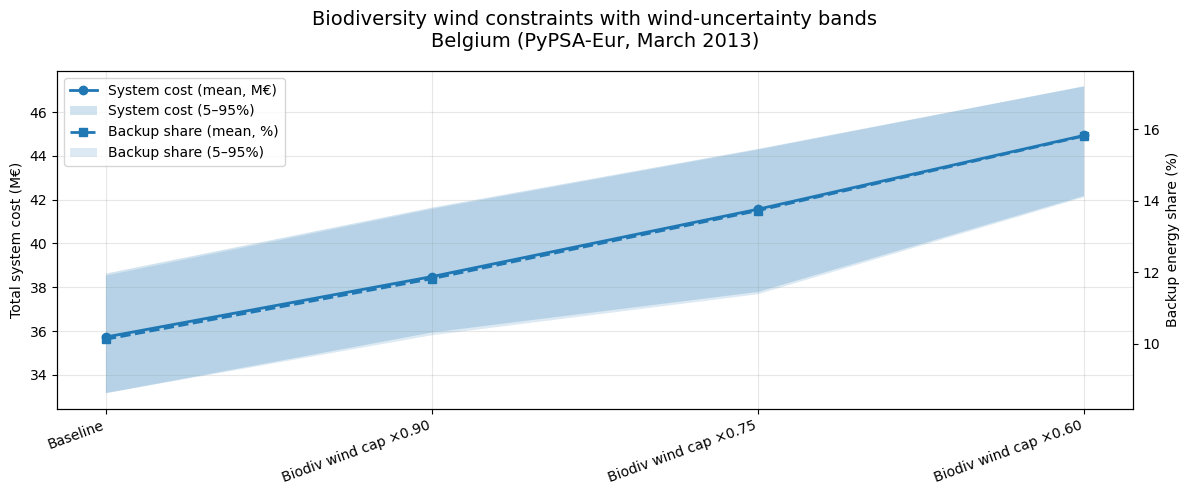

,scenario,obj_mean_MEUR,price_mean,backup_mean
0,Baseline,35.726532,18.876466,0.101316
3,Biodiv wind cap ×0.90,38.485819,20.124842,0.118244
2,Biodiv wind cap ×0.75,41.563125,20.164822,0.137280
1,Biodiv wind cap ×0.60,44.932589,20.202470,0.158134


In [29]:
# -----------------------------
# Load solved network (base)
# -----------------------------
wind_carriers = ["onwind", "offwind-ac", "offwind-dc", "offwind-float"]
wind_gens = n_base.generators.index[n_base.generators.carrier.isin(wind_carriers)]
assert len(wind_gens) > 0, "No wind generators found."

# -----------------------------
# Helpers (same logic as before)
# -----------------------------
def freeze_investments(n: pypsa.Network) -> pypsa.Network:
    n = n.copy()
    if "p_nom_opt" in n.generators.columns:
        n.generators["p_nom"] = n.generators["p_nom_opt"].fillna(n.generators["p_nom"])
    n.generators["p_nom_extendable"] = False
    if len(n.lines) and "s_nom_opt" in n.lines.columns:
        n.lines["s_nom"] = n.lines["s_nom_opt"].fillna(n.lines["s_nom"])
    if len(n.lines):
        n.lines["s_nom_extendable"] = False
    if len(n.links) and "p_nom_opt" in n.links.columns:
        n.links["p_nom"] = n.links["p_nom_opt"].fillna(n.links["p_nom"])
    if len(n.links):
        n.links["p_nom_extendable"] = False
    if len(n.storage_units) and "p_nom_opt" in n.storage_units.columns:
        n.storage_units["p_nom"] = n.storage_units["p_nom_opt"].fillna(n.storage_units["p_nom"])
    if len(n.storage_units):
        n.storage_units["p_nom_extendable"] = False
    if len(n.stores) and "e_nom_opt" in n.stores.columns:
        n.stores["e_nom"] = n.stores["e_nom_opt"].fillna(n.stores["e_nom"])
    if len(n.stores):
        n.stores["e_nom_extendable"] = False
    return n

def backup_share_from_dispatch(n: pypsa.Network, backup=("CCGT","OCGT","oil","biomass")) -> float:
    gen_energy = n.generators_t.p.sum()
    by_carrier = gen_energy.groupby(n.generators.carrier).sum()
    return float(by_carrier.loc[by_carrier.index.intersection(list(backup))].sum() / by_carrier.sum())

def avg_price(n: pypsa.Network) -> float:
    return float(n.buses_t.marginal_price.mean(axis=1).mean())

# -----------------------------
# Define biodiversity scenarios (wind potential reduction)
# -----------------------------
biodiv_caps = [
    ("Baseline", 1.00),
    ("Biodiv wind cap ×0.90", 0.90),
    ("Biodiv wind cap ×0.75", 0.75),
    ("Biodiv wind cap ×0.60", 0.60),
]

# Uncertainty: multiplicative wind shock around each cap
# (interpretation: weather/forecast variability, inter-annual variability, etc.)
N = 60  # keep modest for runtime; increase later
sigma = 0.12  # 12% std dev (illustrative)

rows = []
rng = np.random.default_rng(42)

for scen_name, cap in biodiv_caps:
    shocks = rng.normal(loc=1.0, scale=sigma, size=N).clip(0.6, 1.4)

    for k, shock in enumerate(shocks):
        print(f"Solving {scen_name}: sample {k+1}/{N}")

        n = freeze_investments(n_base)

        scale = cap * shock
        n.generators_t.p_max_pu.loc[:, wind_gens] = (
            n.generators_t.p_max_pu.loc[:, wind_gens] * scale
        ).clip(0, 1)

        with contextlib.redirect_stdout(io.StringIO()), contextlib.redirect_stderr(io.StringIO()):
            n.optimize(
                solver_name="highs",
                solver_options={"log_to_console": False}
            )

        rows.append({
            "scenario": scen_name,
            "cap": cap,
            "shock": shock,
            "objective": float(getattr(n, "objective", np.nan)),
            "avg_price": avg_price(n),
            "backup_share": backup_share_from_dispatch(n),
        })

df_mc = pd.DataFrame(rows)

# -----------------------------
# Summarize into uncertainty bands per scenario
# -----------------------------
def q(x, p): return x.quantile(p)

summary = (df_mc.groupby(["scenario","cap"])
           .agg(obj_mean=("objective","mean"),
                obj_p05=("objective", lambda s: q(s,0.05)),
                obj_p95=("objective", lambda s: q(s,0.95)),
                price_mean=("avg_price","mean"),
                price_p05=("avg_price", lambda s: q(s,0.05)),
                price_p95=("avg_price", lambda s: q(s,0.95)),
                backup_mean=("backup_share","mean"),
                backup_p05=("backup_share", lambda s: q(s,0.05)),
                backup_p95=("backup_share", lambda s: q(s,0.95)))
           .reset_index()
           .sort_values("cap", ascending=False))

# Convert objective to M€ for readability (if objective is in €)
summary["obj_mean_MEUR"] = summary["obj_mean"] / 1e6
summary["obj_p05_MEUR"]  = summary["obj_p05"]  / 1e6
summary["obj_p95_MEUR"]  = summary["obj_p95"]  / 1e6

# -----------------------------
# Plot: single integrated figure
# -----------------------------
x = np.arange(len(summary))
labels = summary["scenario"].tolist()

fig, ax1 = plt.subplots(figsize=(12,5))

# System cost (with band)
ax1.plot(x, summary["obj_mean_MEUR"], marker="o", linewidth=2, label="System cost (mean, M€)")
ax1.fill_between(x, summary["obj_p05_MEUR"], summary["obj_p95_MEUR"], alpha=0.2, label="System cost (5–95%)")
ax1.set_ylabel("Total system cost (M€)")
ax1.set_xticks(x)
ax1.set_xticklabels(labels, rotation=20, ha="right")
ax1.grid(True, alpha=0.3)

# Backup share on twin axis (with band)
ax2 = ax1.twinx()
ax2.plot(x, 100*summary["backup_mean"], marker="s", linestyle="--", linewidth=2, label="Backup share (mean, %)")
ax2.fill_between(x, 100*summary["backup_p05"], 100*summary["backup_p95"], alpha=0.15, label="Backup share (5–95%)")
ax2.set_ylabel("Backup energy share (%)")

fig.suptitle("Biodiversity wind constraints with wind-uncertainty bands\nBelgium (PyPSA-Eur, March 2013)", fontsize=14)

# Merge legends
h1, l1 = ax1.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax1.legend(h1+h2, l1+l2, loc="upper left")

plt.tight_layout()
plt.show()

summary[["scenario","obj_mean_MEUR","price_mean","backup_mean"]]


Increasingly strict biodiversity-related constraints on wind energy (moving from Baseline to wind cap ×0.60) affect electricity system under wind uncertainty. The shaded band around it shows the 5–95% uncertainty range caused by stochastic variation in wind availability. As biodiversity constraints tighten, usable wind potential falls, forcing the system to rely more on higher-cost dispatchable generation. This leads to a clear, monotonic increase in expected system costs. Importantly, the widening uncertainty band indicates that cost risk increases as well: when wind is constrained, adverse wind realizations become more expensive because the system has fewer low-cost flexibility options.

The backup energy share with uncertainty bands, highlights how biodiversity constraints shift not just costs but also system structure and operational stress. As wind availability is restricted, backup technologies (typically fossil-based or biomass generators) are used more frequently, increasing both emissions pressure and land-use intensity elsewhere in the system. From a biodiversity perspective, this reveals a crucial trade-off: protecting ecosystems from wind deployment can indirectly increase pressure through higher backup use, potentially relocating environmental impacts rather than eliminating them. The figure therefore operationalizes biodiversity not merely as a siting constraint, but as a system-wide evaluation criterion, showing how ecological protection decisions propagate through costs, reliability, and risk under uncertainty.